In [8]:
import pandas as pd

In [9]:
# reading the csv file
df_population_raw = pd.read_csv('population_total.csv')

In [10]:
# first look at the dataset
df_population_raw

,country,year,population
0,China,2020.0,1.439324e+09
1,China,2019.0,1.433784e+09
2,China,2018.0,1.427648e+09
3,China,2017.0,1.421022e+09
4,China,2016.0,1.414049e+09
...,...,...,...
4180,United States,1965.0,1.997337e+08
4181,United States,1960.0,1.867206e+08
4182,United States,1955.0,1.716853e+08
4183,India,1960.0,4.505477e+08


# 1. Making a Pivot Table

.pivot(): Returns reshaped DataFrame organized by given index / column values ("pivot without aggregation")

In [11]:
# dropping null values
df_population_raw.dropna(inplace=True)

In [12]:
# making pivot table
df_pivot = df_population_raw.pivot(index='year', columns='country', 
                                    values='population')

In [13]:
# Selecting some countries
df_pivot = df_pivot[['United States','India', 'China', 'Indonesia', 'Brazil']]

In [14]:
# Showing pivot table
df_pivot

country,United States,India,China,Indonesia,Brazil
year,,,,,
1955.0,171685336.0,4.098806e+08,6.122416e+08,77273425.0,62533919.0
1960.0,186720571.0,4.505477e+08,6.604081e+08,87751068.0,72179226.0
1965.0,199733676.0,4.991233e+08,7.242190e+08,100267062.0,83373530.0
1970.0,209513341.0,5.551898e+08,8.276014e+08,114793178.0,95113265.0
1975.0,219081251.0,6.231029e+08,9.262409e+08,130680727.0,107216205.0
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1985.0,240499825.0,7.843600e+08,1.075589e+09,164982451.0,135274080.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
1995.0,265163745.0,9.639226e+08,1.240921e+09,196934260.0,162019896.0


# 2. Lineplot

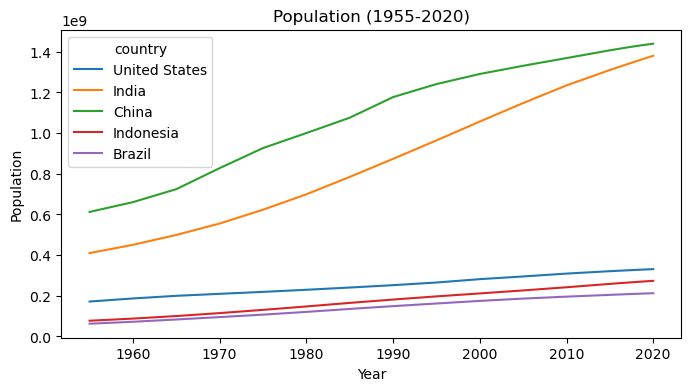

In [20]:
df_pivot.plot(kind='line', xlabel='Year', ylabel='Population', 
              title='Population (1955-2020)', 
              figsize=(8,4));

In [18]:
# So in this lineplot we can quickly see the evolution of the population throughout the years
# For example, China and India, which are the green and orange lines, they had a faster growing
# population compared to the other countries. While United States, Indonesia and Brazil, they
# had a lower population, and also their populations didn't grow up so much, their population increased
# much slower in comparison to China and India, in the past 50 years.

# 3. Barplot

## 3.1 Single Barplot

In [24]:
# Selecting only one year (2020)
df_pivot_2020 = df_pivot[df_pivot.index.isin([2020])]

In [23]:
# and the result is this df and it only contains the population per country in the year 2020

In [25]:
# showing new dataframe
df_pivot_2020 

country,United States,India,China,Indonesia,Brazil
year,,,,,
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


In [29]:
# transpose dataframe from rows to columns or viceversa
df_pivot_2020 = df_pivot_2020.T
df_pivot_2020

year,2020.0
country,
United States,3.310027e+08
India,1.380004e+09
China,1.439324e+09
Indonesia,2.735236e+08
Brazil,2.125594e+08


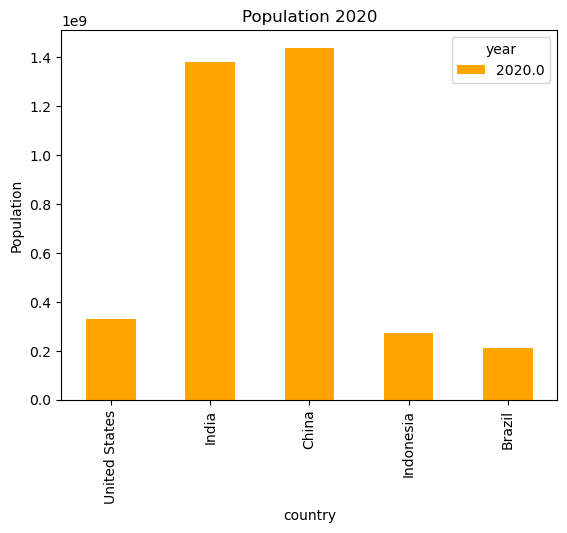

In [35]:
# making barplot
df_pivot_2020.plot(kind='bar', color='orange', ylabel='Population',
                  title='Population 2020');

## 3.2 Barplot grouped by "n" variables

In [38]:
# Selecting a few years
df_pivot_sample = df_pivot[df_pivot.index.isin([1980, 1990, 2000, 2010, 2020])]
df_pivot_sample

country,United States,India,China,Indonesia,Brazil
year,,,,,
1980.0,229476354.0,6.989528e+08,1.000089e+09,147447836.0,120694009.0
1990.0,252120309.0,8.732778e+08,1.176884e+09,181413402.0,149003223.0
2000.0,281710909.0,1.056576e+09,1.290551e+09,211513823.0,174790340.0
2010.0,309011475.0,1.234281e+09,1.368811e+09,241834215.0,195713635.0
2020.0,331002651.0,1.380004e+09,1.439324e+09,273523615.0,212559417.0


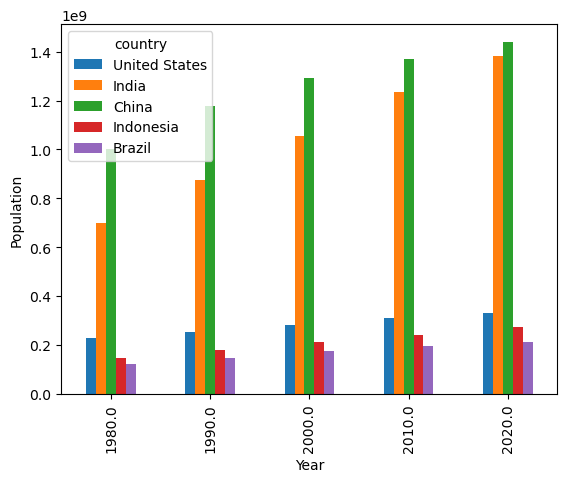

In [41]:
# making grouped barplot
df_pivot_sample.plot(kind='bar', xlabel='Year', ylabel='Population');

In [ ]:
# And now as we can see here, we have the bar plots grouped by year

# 4. Piechart

In [43]:
# changing column name
df_pivot_2020.rename(columns={2020:'2020'}, inplace=True)

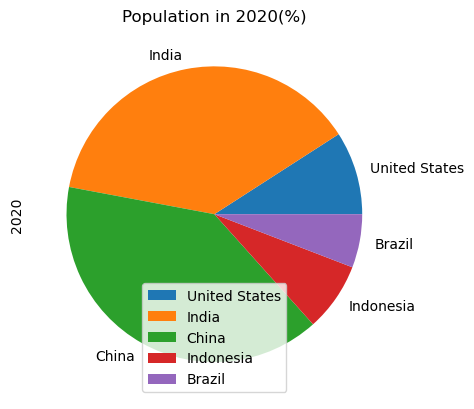

In [46]:
# making the plot
df_pivot_2020.plot(kind='pie', y='2020', title='Population in 2020(%)');

# 5. Boxplot

## 5.1 Single Boxplot

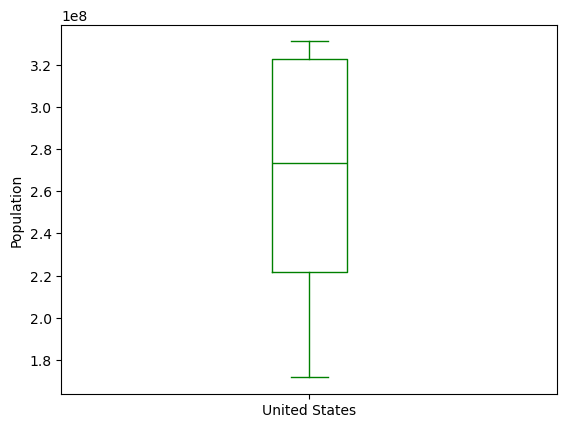

In [49]:
df_pivot['United States'].plot(kind='box', color='green',
                               ylabel='Population');

In [50]:
# This boxplot contains five important values (the min, Q1, the median, Q3 and the max).
# the min value is approximately 1.7e8 habitants, the first quartile is 2.2e8, then
# the median is approximately 2.7e8, the third quartile is 3.2e8 and the max value is 3.3e8.

## 5.2 Multiple Boxplot

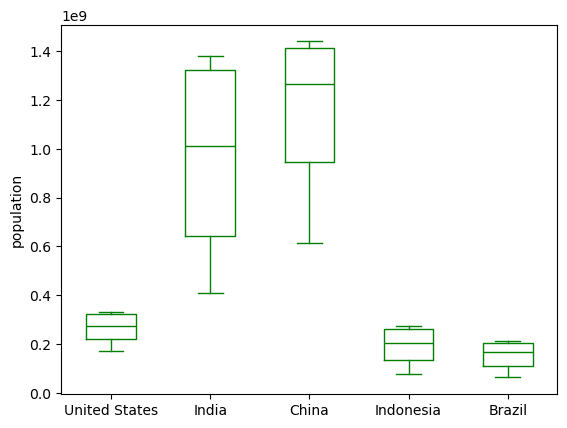

In [52]:
# we're going to get one boxplot per country

df_pivot.plot(kind='box', color='green', ylabel='population');

In [ ]:
# and here we got five boxplots and each of them represent how the data is spread in the df for each country

# 6. Histogram

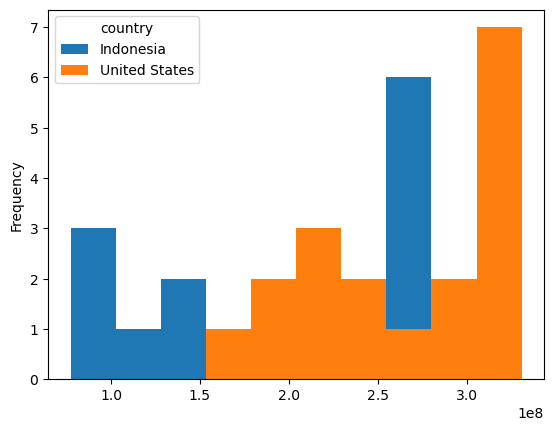

In [58]:
df_pivot[['Indonesia','United States']].plot(kind='hist');

# 7. ScatterPlot

In [59]:
# selecting a sample of the raw data
df_sample = df_population_raw[df_population_raw['country'].isin(['United States','India',
                                               'China','Indonesia','Brazil'])]

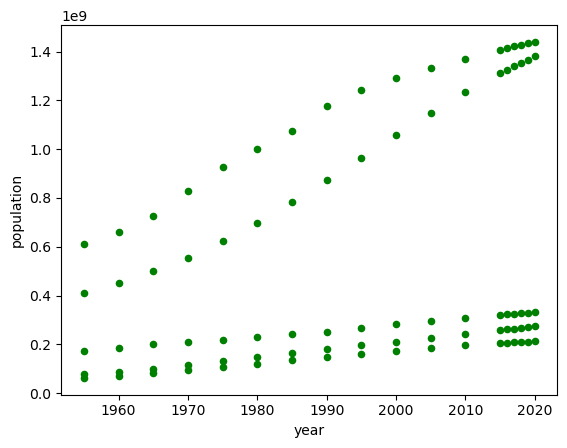

In [65]:
# creating the plot
df_sample.plot(kind='scatter', x='year', y='population', color='green');